In [30]:
import pandas as pd

# --- Passo 1: Defina a URL da Planilha Google ---
google_sheet_url = 'https://docs.google.com/spreadsheets/d/1SQiuZP_ON7dy539dXaMJv9VW3SgLLqbbgAphAqQmB0w/export?format=csv&gid=48792188'

try:
    # --- Passo 2: Ler a planilha diretamente para um DataFrame ---
    # O pandas consegue ler um CSV diretamente de uma URL
    df = pd.read_csv(google_sheet_url)
    print("Dados carregados com sucesso da Planilha Google!")

    # --- Verificação Final ---
    print("\nAs 5 primeiras linhas do DataFrame:")
    # No Kaggle/Jupyter, display() é mais elegante que print() para DataFrames
    display(df.head())

except Exception as e:
    print(f"Ocorreu um erro ao tentar ler a planilha: {e}")
    print("\nPossíveis causas:")
    print("1. A URL está incorreta.")
    print("2. A planilha não está compartilhada como 'Qualquer pessoa com o link pode ver'.")

Dados carregados com sucesso da Planilha Google!

As 5 primeiras linhas do seu DataFrame:


,Nome,Carteirinha,Idade,Genero,Endereco,Dependentes,TipoContrato,CID,CategoriaCID,CustoMensal_12M,NumeroInternacoes_12M,NumeroConsultas_12M,NumeroConsultasEmergencia_12M,ConsultasEmergencia_3M,DiasDesdeUltimaInternacao,ProporcaoEmergencias_12M,ProbabilidadeRisco,Reinternado_30_Dias
0,Arthur Alves,69958471509,25,Masculino,"R. Carlos Osternack, 144 - Jardim Estrela, Pon...",5,Coletivo,NaN,Nenhuma,798.17,0,0,1,1,9999,0.00,0.0372,False
1,Bernardo Martins,69416795194,29,Masculino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",4,Individual,NaN,Nenhuma,529.66,0,1,1,0,9999,1.00,0.0181,False
2,Maria Ferreira,69380729510,36,Feminino,"Rua Anita Garibaldi, 1577 - Órfãs, Ponta Gross...",5,Coletivo,NaN,Nenhuma,353.49,0,4,1,0,9999,0.25,0.0683,False
3,Heloísa Fernandes,69174025827,57,Feminino,"Av. Monteiro Lobato, 1951 - Jardim Carvalho, P...",5,Familiar,J42,Respiratório,2202.11,1,8,4,4,42,0.50,0.5705,True
4,Miguel Ribeiro,69921328911,28,Masculino,"R. Sen. Flávio C. Guimarães, 1250 - Boa Vista,...",3,Familiar,NaN,Nenhuma,353.94,0,0,1,0,9999,0.00,0.0585,False


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# Separa as features (X) do alvo (y)
X = df.drop(['Nome', 'Carteirinha', 'Reinternado_30_Dias', 'ProbabilidadeRisco'], axis=1)
y = df['Reinternado_30_Dias']

# Identifica colunas numéricas e categóricas
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Cria o pipeline de pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])


# Divide os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados preparados e divididos para o treinamento.")

Dados preparados e divididos para o treinamento.


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Cria o pipeline final que junta o pré-processador com o modelo
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))])

# --- CALCULAR OS PESOS ---
# Isso vai dar um peso maior para a classe minoritária (Reinternado_30_Dias = True)
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Treina o modelo com os dados de treino
print("Iniciando o treinamento do modelo...")
model_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)
print("Treinamento concluído!")

Iniciando o treinamento do modelo...
Treinamento concluído!


\n--- AVALIAÇÃO DO MODELO ---
              precision    recall  f1-score   support

       False       0.90      0.76      0.83       168
        True       0.31      0.56      0.40        32

    accuracy                           0.73       200
   macro avg       0.61      0.66      0.61       200
weighted avg       0.81      0.73      0.76       200

AUC-ROC Score: 0.7429


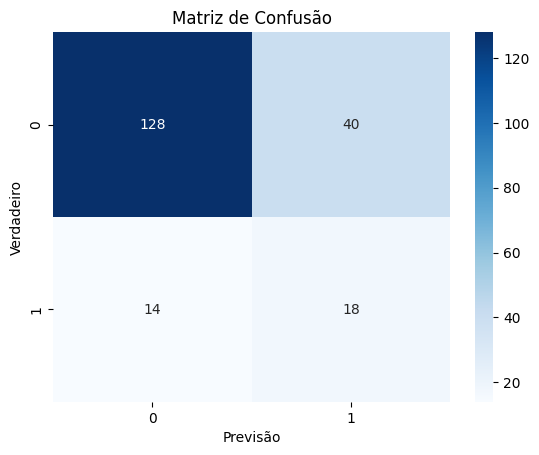

In [25]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("\\n--- AVALIAÇÃO DO MODELO ---")
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsão')
plt.show()

In [33]:
# Usar o modelo para prever a probabilidade de risco para TODOS os pacientes
full_data_predictions = model_pipeline.predict_proba(X)[:, 1]

# Criar um DataFrame com os resultados
df_resultados = pd.DataFrame({
    'Nome': df['Nome'],
    'Carteirinha': df['Carteirinha'],
    'Idade': df['Idade'],
    'Genero': df['Genero'],
    'Endereco' : df['Endereco'],
    'Dependentes' : df['Dependentes'],
    'TipoContrato' : df['TipoContrato'],
    'ScoreRisco_Preditivo': full_data_predictions
})

# Ordenar pela maior probabilidade de risco
df_resultados = df_resultados.sort_values(by='ScoreRisco_Preditivo', ascending=False)

# Salvar o resultado em um arquivo CSV
df_resultados.to_csv('previsoes_finais.csv', index=False)

print("\\nArquivo 'previsoes_finais.csv' gerado com sucesso!")
print("As 5 maiores prioridades de atendimento são:")
display(df_resultados.head())

\nArquivo 'previsoes_finais.csv' gerado com sucesso!
As 5 maiores prioridades de atendimento são:


,Nome,Carteirinha,Idade,Genero,Endereco,Dependentes,TipoContrato,ScoreRisco_Preditivo
650,Sophia Martins,69176732845,78,Feminino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",0,Familiar,0.933486
775,Heloísa Vieira,69208803817,86,Feminino,"R. Ermelino de Leão, 703 - Olarias, Ponta Gros...",5,Familiar,0.926875
331,Heitor Silva,69402783162,80,Masculino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",4,Familiar,0.923811
320,Sophia Pereira,69774373945,87,Feminino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",5,Familiar,0.921833
705,Theo Carvalho,69246272605,80,Masculino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",1,Familiar,0.919410


\n--- AVALIAÇÃO COM LIMIAR DE 30.0% ---
              precision    recall  f1-score   support

       False       0.94      0.67      0.78       168
        True       0.31      0.78      0.45        32

    accuracy                           0.69       200
   macro avg       0.63      0.73      0.62       200
weighted avg       0.84      0.69      0.73       200

\n--- MATRIZ DE CONFUSÃO COM NOVO LIMIAR ---


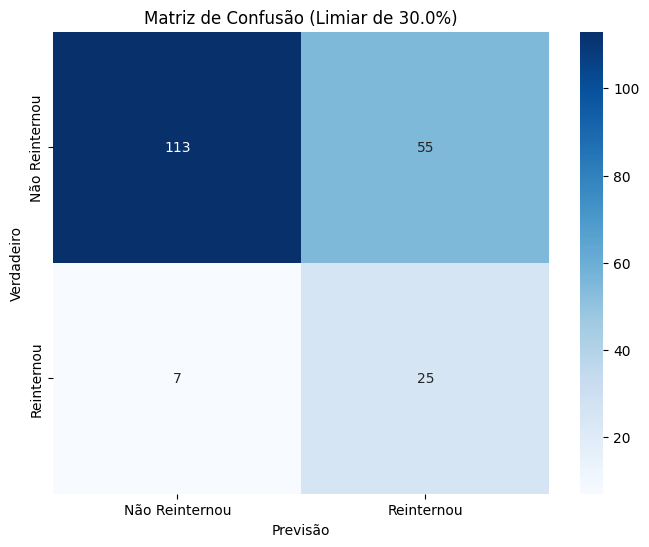

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Seu código existente ---
# Pega as probabilidades em vez da previsão final
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

# --- NOVA LINHA: DEFINIR UM NOVO LIMIAR ---
novo_limiar = 0.30

# Faz a previsão com base no novo limiar
y_pred_novo_limiar = (y_pred_proba >= novo_limiar).astype(int)

print(f"\\n--- AVALIAÇÃO COM LIMIAR DE {novo_limiar*100}% ---")
print(classification_report(y_test, y_pred_novo_limiar))


# --- CÓDIGO ADICIONADO PARA GERAR A MATRIZ DE CONFUSÃO ---

print("\\n--- MATRIZ DE CONFUSÃO COM NOVO LIMIAR ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_test, y_pred_novo_limiar)

# Desenha a matriz de forma visual
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Reinternou', 'Reinternou'],
            yticklabels=['Não Reinternou', 'Reinternou'])
plt.title(f'Matriz de Confusão (Limiar de {novo_limiar*100}%)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsão')
plt.show()

In [28]:
!pip install gspread google-auth

In [35]:
from google.colab import auth
from google.auth import default
import gspread
import pandas as pd

# Authenticate to Google
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# --- Passo 1: Definir o nome da Planilha Google e a aba ---
spreadsheet_name = 'ResultadosUnimed'
worksheet_name = 'PacientesAltoRisco'

# --- Passo 2: Filtrar pacientes com Score de Risco Preditivo >= 0.65 ---
score_minimo = 0.65
df_alto_risco = df_resultados[df_resultados['ScoreRisco_Preditivo'] >= score_minimo].copy()

# --- Passo 3: Adicionar o novo campo booleano 'Visitado' ---
# O valor inicial é False, indicando que a visita ainda não foi realizada
df_alto_risco['Visitado'] = False

print("Pacientes com Score de Risco >= 0.65 e Coluna 'Visitado':")
display(df_alto_risco)


try:
    # --- Passo 4: Abrir a planilha e selecionar a aba ---
    sh = gc.open(spreadsheet_name)
    ws = sh.worksheet(worksheet_name)

    # --- Passo 5: Limpar o conteúdo existente na aba ---
    ws.clear()

    # --- Passo 6: Escrever os dados do DataFrame para a planilha ---
    # Converter o DataFrame para uma lista de listas (formato que gspread entende)
    data_to_write = [df_alto_risco.columns.tolist()] + df_alto_risco.values.tolist()

    # Escrever os dados na planilha
    ws.update(data_to_write)

    print(f"\nDados exportados com sucesso para a planilha '{spreadsheet_name}' na aba '{worksheet_name}'!")

except Exception as e:
    print(f"Ocorreu um erro ao tentar escrever na planilha: {e}")
    print("\nPossíveis causas:")
    print("1. O nome da planilha ou da aba está incorreto.")
    print("2. Você não tem permissão de escrita na planilha.")
    print("3. A autenticação não foi bem-sucedida.")

Pacientes com Score de Risco >= 0.65 e Coluna 'Visitado':


,Nome,Carteirinha,Idade,Genero,Endereco,Dependentes,TipoContrato,ScoreRisco_Preditivo,Visitado
650,Sophia Martins,69176732845,78,Feminino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",0,Familiar,0.933486,False
775,Heloísa Vieira,69208803817,86,Feminino,"R. Ermelino de Leão, 703 - Olarias, Ponta Gros...",5,Familiar,0.926875,False
331,Heitor Silva,69402783162,80,Masculino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",4,Familiar,0.923811,False
320,Sophia Pereira,69774373945,87,Feminino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",5,Familiar,0.921833,False
705,Theo Carvalho,69246272605,80,Masculino,"R. Doutor Washington Subtil Chueire, 333 - Jar...",1,Familiar,0.919410,False
...,...,...,...,...,...,...,...,...,...
670,Maitê Gomes,69169993718,81,Feminino,"Av. Pres. Kennedy, 1262 - Contorno, Ponta Gros...",5,Familiar,0.657581,False
490,Sophia Costa,69133544064,65,Feminino,"Av. Souza Naves, 3264 - Sala 1 - Chapada, Pont...",5,Familiar,0.657581,False
691,Arthur Ferreira,69982587333,55,Masculino,"R. Benjamin Constant, 571 - Centro, Ponta Gros...",5,Familiar,0.652479,False
203,Maitê Carvalho,69922840315,50,Feminino,"R. Ermelino de Leão, 703 - Olarias, Ponta Gros...",2,Familiar,0.652479,False



Dados exportados com sucesso para a planilha 'ResultadosUnimed' na aba 'PacientesAltoRisco'!
